In [1]:
from fastai.vision.all import *
path = untar_data(URLs.PETS)

In [2]:
Path.BASE_PATH = path

In [3]:
path.ls()


[Path('annotations'), Path('images')]

In [4]:
(path/"images").ls()

(#7393) [Path('images/japanese_chin_31.jpg'), Path('images/staffordshire_bull_terrier_186.jpg'), Path('images/great_pyrenees_140.jpg'), Path('images/english_setter_159.jpg'), Path('images/japanese_chin_182.jpg'), Path('images/pomeranian_115.jpg'), Path('images/newfoundland_144.jpg'), Path('images/samoyed_116.jpg'), Path('images/Egyptian_Mau_140.jpg'), Path('images/leonberger_65.jpg'), Path('images/Egyptian_Mau_149.jpg'), Path('images/english_setter_39.jpg'), Path('images/chihuahua_71.jpg'), Path('images/Abyssinian_151.jpg'), Path('images/Sphynx_195.jpg'), Path('images/miniature_pinscher_31.jpg'), Path('images/beagle_136.jpg'), Path('images/shiba_inu_49.jpg'), Path('images/german_shorthaired_45.jpg'), Path('images/boxer_97.jpg'), Path('images/leonberger_153.jpg'), Path('images/pomeranian_94.jpg'), Path('images/Siamese_51.jpg'), Path('images/beagle_105.jpg'), Path('images/Birman_172.jpg'), Path('images/pug_10.jpg'), Path('images/keeshond_91.jpg'), Path('images/havanese_71.jpg'), Path('im

In [5]:
fname=(path/"images").ls()[0]
fname

Path('images/japanese_chin_31.jpg')

In [6]:
import re
re.findall(r'(.+)_\d+.jpg$', fname.name)

['japanese_chin']

In [7]:
pets = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(seed=42),
                 get_y=using_attr(RegexLabeller(r'(.+)_\d+.jpg$'), 'name'),
                 item_tfms=Resize(460),
                 batch_tfms=aug_transforms(size=224, min_scale=0.75))
dls = pets.dataloaders(path/"images")

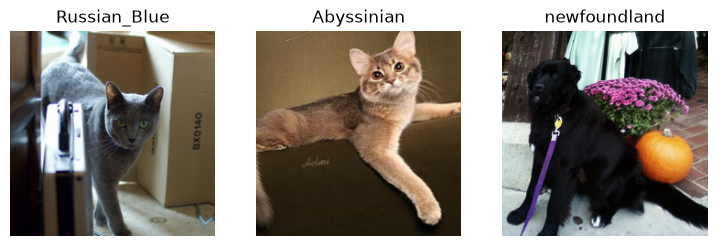

In [8]:
dls.show_batch(nrows=1,ncols=3)

In [9]:
learn= vision_learner(dls, resnet34 , metrics=error_rate)
learn.fine_tune(2)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /home/z004psfe/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████████████████████████████████████████████████████████████████████████| 83.3M/83.3M [00:03<00:00, 26.3MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.522210,0.319148,0.097429,08:40


epoch,train_loss,valid_loss,error_rate,time
0,0.506754,0.357470,0.113667,13:03
1,0.336451,0.223607,0.062246,13:34


<div></div>

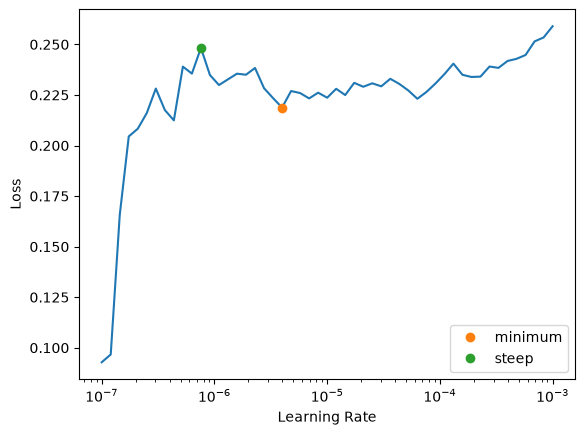

In [10]:
earn = vision_learner(dls, resnet34, metrics=error_rate)
lr_min,lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))

In [11]:
print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}")

Minimum/10: 3.98e-07, steepest point: 7.59e-07


In [12]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fit_one_cycle(3, 3e-6)

epoch,train_loss,valid_loss,error_rate,time
0,5.400176,4.264221,0.976996,08:33
1,5.301602,4.184600,0.973613,09:54
2,5.220376,4.155048,0.973613,09:32


In [13]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fit_one_cycle(3, 3e-3)

epoch,train_loss,valid_loss,error_rate,time
0,1.141689,0.322555,0.097429,09:36
1,0.520112,0.247274,0.080514,10:56
2,0.322210,0.222463,0.064953,11:02


In [14]:
learn.unfreeze()

<div></div>

SuggestedLRs(valley=2.75422871709452e-06)

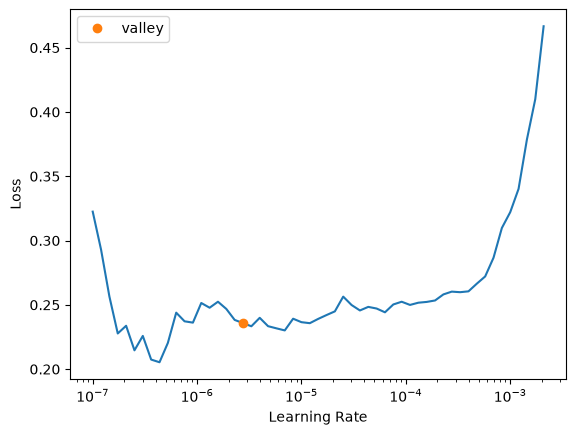

In [15]:
learn.lr_find()

In [ ]:
learn.fit_one_cycle(12, lr_max=slice(1e-6,1e-4))

epoch,train_loss,valid_loss,error_rate,time
0,0.239135,0.216675,0.066306,14:26
1,0.248529,0.209696,0.063599,14:49
2,0.232416,0.204643,0.062923,15:23
3,0.203325,0.205147,0.063599,14:05
4,0.206875,0.198545,0.061570,14:12
5,0.174508,0.195701,0.057510,14:20
6,0.153018,0.195140,0.055480,15:00
7,0.143057,0.193236,0.056157,14:15
8,0.128546,0.187692,0.052097,14:14
9,0.126312,0.191026,0.056834,14:12
